# Parameter Scan Exploration — Desktop World DAU (June 2026)

Human-mediated gradient-descent exploration of Prophet parameters in `DesktopModelConfig`,
aiming to bring the **June 2026 desktop world DAU forecast at 2026-12-15** up to match
the **April 2026 baseline**.

Workflow:
1. Pick a config (start from the suggestions in the empty-state cell).
2. Run it manually with `scripts/run_param_scan.py`. Each run writes into
   `param_scan_results/<slug>/`.
3. Reload this notebook (re-run the loader cell). The summary table and plots
   refresh automatically.
4. Use the **next-step recommendation** cell to pick the next config(s) to try.
5. Repeat until Dec 15 desktop world DAU is within tolerance of the April baseline.

Scope: **desktop, world (country='ALL'), os='ALL', DAU**. Mobile is excluded.


In [1]:
# [setup]
import json
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root (notebook lives at repo root)
REPO_ROOT = Path.cwd()
assert (REPO_ROOT / "src" / "mozaic_daily").exists(), f"Expected to be at repo root, got {REPO_ROOT}"

# Make mozaic_daily importable so we can route reads through load_forecast()
SRC_PATH = REPO_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))
from mozaic_daily.adjustments import load_forecast  # noqa: E402

# Baselines (no-Iran world DAU, country=ALL, segment os=ALL). Both are .raw.
# The June baseline is the **cap-426** rerun (2026-05-18) — the rolling-cap window
# widened from 366 to 426 days in mozaic-forecasting-official, which closed ~70%
# of the original gap to April on its own. See logistic-cap-artifact memory.
APRIL_BASELINE_PARQUET = REPO_ROOT / "data-official/2026-04/desktop_cps0.15983_thresh050_recent13_clip0.6/mozaic_daily_forecast.2026-04-01.ld-D.raw.parquet"
JUNE_BASELINE_PARQUET  = REPO_ROOT / "data-official/2026-06/desktop_cps0.15983_thresh032_recent13_clip0.6_cap426/mozaic_daily_forecast.2026-05-17.ld-D.raw.parquet"
SCAN_RESULTS_DIR       = REPO_ROOT / "param_scan_results"

TARGET_DATE = pd.Timestamp("2026-12-15")

print(f"Repo root:           {REPO_ROOT}")
print(f"April baseline:      {APRIL_BASELINE_PARQUET}  (exists={APRIL_BASELINE_PARQUET.exists()})")
print(f"June  baseline:      {JUNE_BASELINE_PARQUET}  (exists={JUNE_BASELINE_PARQUET.exists()})")
print(f"Scan results dir:    {SCAN_RESULTS_DIR}  (exists={SCAN_RESULTS_DIR.exists()})")


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


Repo root:           /Users/brendanwells/work/mozaic-daily
April baseline:      /Users/brendanwells/work/mozaic-daily/data-official/2026-04/desktop_cps0.15983_thresh050_recent13_clip0.6/mozaic_daily_forecast.2026-04-01.ld-D.raw.parquet  (exists=True)
June  baseline:      /Users/brendanwells/work/mozaic-daily/data-official/2026-06/desktop_cps0.15983_thresh032_recent13_clip0.6_cap426/mozaic_daily_forecast.2026-05-17.ld-D.raw.parquet  (exists=True)
Scan results dir:    /Users/brendanwells/work/mozaic-daily/param_scan_results  (exists=True)


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# [helpers]
def world_desktop_dau_at(parquet_path: Path, target_date: pd.Timestamp,
                          ma_window: int = 1) -> float:
    """Return desktop world DAU at target_date for country='ALL', segment os='ALL'.

    Loads via ``load_forecast(path, require_state=[])``, so the file must be a
    ``.raw.`` parquet with a valid sidecar meta. Headwind-adjusted or
    state-unmarked files are rejected.

    Args:
        parquet_path: Path to a mozaic_daily_forecast.*.ld-D.raw.parquet (or full forecast).
        target_date: The date to extract the value at.
        ma_window: If >1, returns a trailing window average ending at target_date.

    Returns:
        DAU value (float). NaN if the date or slice is missing.
    """
    df, _meta = load_forecast(parquet_path, require_state=[])
    df = df[df["country"] == "ALL"]
    df = df[df["segment"] == '{"os": "ALL"}']
    df = df.copy()
    df["target_date"] = pd.to_datetime(df["target_date"])
    if ma_window > 1:
        end = target_date
        start = target_date - pd.Timedelta(days=ma_window - 1)
        window = df[(df["target_date"] >= start) & (df["target_date"] <= end)]
        if window.empty:
            return float("nan")
        return float(window["dau"].mean())
    point = df[df["target_date"] == target_date]
    if point.empty:
        return float("nan")
    return float(point["dau"].iloc[0])


# Slug regex matches both the *old* style (cps0.15983_thresh50_recent13_clip0.6)
# and the *new* style (cps..._thresh..._recent..._cpr..._ncp..._clip...).
SLUG_PATTERN_NEW = re.compile(
    r"^cps(?P<cps>[\d.]+)"
    r"_thresh(?P<thresh>\d+)"
    r"_recent(?P<recent>\d+)"
    r"_cpr(?P<cpr>[\d.]+)"
    r"_ncp(?P<ncp>\d+)"
    r"_clip(?P<clip>[\d.]+)$"
)
SLUG_PATTERN_OLD = re.compile(
    r"^cps(?P<cps>[\d.]+)"
    r"_thresh(?P<thresh>\d+)"
    r"_recent(?P<recent>\d+)"
    r"_clip(?P<clip>[\d.]+)$"
)


def parse_slug(slug: str) -> dict | None:
    """Parse a config slug; return dict of param fields or None if unrecognized."""
    m = SLUG_PATTERN_NEW.match(slug)
    if m:
        return {
            "changepoint_prior_scale": float(m["cps"]),
            "holiday_threshold": -int(m["thresh"]) / 1000.0,
            "recent_weeks": int(m["recent"]),
            "changepoint_range": float(m["cpr"]),
            "n_changepoints": int(m["ncp"]),
            "holiday_effect_floor": -float(m["clip"]),
        }
    m = SLUG_PATTERN_OLD.match(slug)
    if m:
        return {
            "changepoint_prior_scale": float(m["cps"]),
            "holiday_threshold": -int(m["thresh"]) / 1000.0,
            "recent_weeks": int(m["recent"]),
            "changepoint_range": None,
            "n_changepoints": None,
            "holiday_effect_floor": -float(m["clip"]),
        }
    return None


def load_scan_results(results_dir: Path, target_date: pd.Timestamp,
                      ma_window: int = 1) -> pd.DataFrame:
    """Walk results_dir, load each raw forecast parquet, return one row per slug.

    Only ``.raw.parquet`` files are picked up — the glob requires the state
    marker so a stale unmarked or adj-h file in a slug dir cannot contaminate
    the comparison. Prefers parameters.json (authoritative) for param values;
    falls back to parsing the slug if parameters.json is missing.
    """
    rows = []
    if not results_dir.exists():
        return pd.DataFrame()

    for slug_dir in sorted(p for p in results_dir.iterdir() if p.is_dir()):
        slug = slug_dir.name

        # Require .raw. marker — load_forecast(require_state=[]) enforces it below
        parquets = sorted(slug_dir.glob("mozaic_daily_forecast.*.ld-D.raw.parquet"))
        if not parquets:
            print(f"[skip] {slug}: no mozaic_daily_forecast.*.ld-D.raw.parquet")
            continue
        forecast_path = parquets[-1]  # most recent

        # Param values: prefer parameters.json
        params_path = slug_dir / "parameters.json"
        if params_path.exists():
            payload = json.loads(params_path.read_text())
            config = payload.get("config", payload)  # tolerate older shape
            params = {
                "changepoint_prior_scale": config.get("prophet_changepoint_prior_scale"),
                "recent_weeks":            config.get("prophet_recent_weeks"),
                "changepoint_range":       config.get("prophet_changepoint_range"),
                "n_changepoints":          config.get("prophet_n_changepoints"),
                "holiday_threshold":       config.get("holiday_threshold"),
                "holiday_max_radius":      config.get("holiday_max_radius"),
                "holiday_min_radius":      config.get("holiday_min_radius"),
                "holiday_effect_floor":    config.get("holiday_effect_floor"),
            }
        else:
            parsed = parse_slug(slug)
            if parsed is None:
                print(f"[skip] {slug}: unrecognized slug and no parameters.json")
                continue
            params = parsed

        dau = world_desktop_dau_at(forecast_path, target_date, ma_window=ma_window)
        rows.append({"slug": slug, "forecast_path": str(forecast_path),
                     **params, "dec15_world_dau": dau})

    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).set_index("slug").sort_values("dec15_world_dau")


In [3]:
# [baselines]
# Compute baseline values for reference lines on plots.
# Both point and 28-day trailing MA, since either could be the target metric.

baselines = {
    "april_point":  world_desktop_dau_at(APRIL_BASELINE_PARQUET, TARGET_DATE, ma_window=1),
    "april_ma28":   world_desktop_dau_at(APRIL_BASELINE_PARQUET, TARGET_DATE, ma_window=28),
    "june_point":   world_desktop_dau_at(JUNE_BASELINE_PARQUET,  TARGET_DATE, ma_window=1),
    "june_ma28":    world_desktop_dau_at(JUNE_BASELINE_PARQUET,  TARGET_DATE, ma_window=28),
}

print("Reference values at 2026-12-15 (desktop world DAU, no-Iran):")
for k, v in baselines.items():
    print(f"  {k:14s}: {v:>14,.0f}")

# Gap the scan is trying to close (point estimates):
gap_point = baselines["april_point"] - baselines["june_point"]
gap_ma28  = baselines["april_ma28"]  - baselines["june_ma28"]
print(f"\nGap to close (April − June, point): {gap_point:+,.0f}")
print(f"Gap to close (April − June, 28d MA): {gap_ma28:+,.0f}")


Reference values at 2026-12-15 (desktop world DAU, no-Iran):
  april_point   :     53,367,728
  april_ma28    :     48,389,006
  june_point    :     53,229,733
  june_ma28     :     48,294,335

Gap to close (April − June, point): +137,995
Gap to close (April − June, 28d MA): +94,672


In [4]:
# [load-results]
# Load all scan runs in param_scan_results/ and compute deltas vs baselines.
# Re-run this cell after each new param_scan run to refresh.

results = load_scan_results(SCAN_RESULTS_DIR, TARGET_DATE, ma_window=1)

if results.empty:
    print("=" * 70)
    print("No scan runs found in", SCAN_RESULTS_DIR)
    print("=" * 70)
    print("Run scripts/run_param_scan.py first. See the 'empty-state' cell below")
    print("for suggested starting configs.")
else:
    results = results.copy()
    results["delta_vs_april"] = results["dec15_world_dau"] - baselines["april_point"]
    results["delta_vs_june_baseline"] = results["dec15_world_dau"] - baselines["june_point"]
    cols = [
        "changepoint_prior_scale", "recent_weeks", "changepoint_range",
        "n_changepoints", "holiday_threshold", "holiday_effect_floor",
        "dec15_world_dau", "delta_vs_april", "delta_vs_june_baseline",
    ]
    print(f"{len(results)} run(s) loaded.\n")
    print(results[cols].to_string(float_format=lambda x: f"{x:,.4g}"))


44 run(s) loaded.

                                                       changepoint_prior_scale  recent_weeks  changepoint_range  n_changepoints  holiday_threshold  holiday_effect_floor  dec15_world_dau  delta_vs_april  delta_vs_june_baseline
slug                                                                                                                                                                                                                             
cps0.15983_thresh032_recent8_cpr0.7_ncp25_clip0.6                       0.1598             8                0.7              25             -0.032                  -0.6        5.246e+07      -9.053e+05              -7.673e+05
cps0.07983_thresh050_recent13_cpr0.7_ncp25_clip0.6                     0.07983            13                0.7              25              -0.05                  -0.6        5.314e+07      -2.321e+05              -9.406e+04
cps0.23983_thresh050_recent13_cpr0.7_ncp25_clip0.6                      0.239

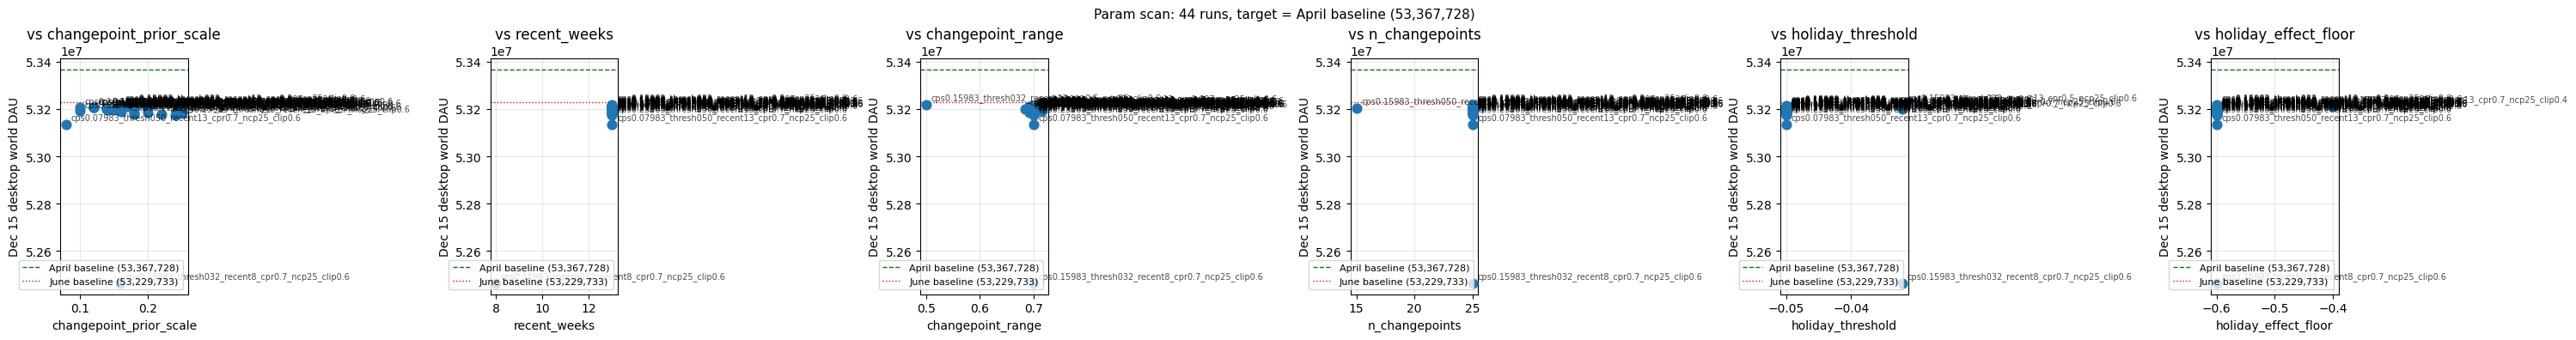

In [5]:
# [plots]
# Scatter Dec 15 DAU vs each varied parameter. For each parameter, only the
# runs where that parameter varies (>=2 distinct values) get a panel.
# Reference lines: April baseline (target) and June baseline (starting point).

SCAN_PARAMS = [
    "changepoint_prior_scale",
    "recent_weeks",
    "changepoint_range",
    "n_changepoints",
    "holiday_threshold",
    "holiday_effect_floor",
]


def plot_param_scan(df: pd.DataFrame, baselines: dict) -> None:
    if df.empty:
        print("No data to plot — run scripts/run_param_scan.py first.")
        return

    varied = [p for p in SCAN_PARAMS if df[p].nunique(dropna=True) >= 2]
    if not varied:
        print("Only one run loaded; no parameter varies yet. Plotting a single point.")
        varied = ["changepoint_prior_scale"]  # show *something*

    n = len(varied)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)
    axes = axes[0]

    for ax, param in zip(axes, varied):
        sub = df.dropna(subset=[param, "dec15_world_dau"])
        ax.scatter(sub[param], sub["dec15_world_dau"], s=60, zorder=3)
        for slug, row in sub.iterrows():
            ax.annotate(slug, (row[param], row["dec15_world_dau"]),
                        xytext=(4, 4), textcoords="offset points",
                        fontsize=7, alpha=0.7)

        ax.axhline(baselines["april_point"], color="green", linestyle="--",
                   linewidth=1, label=f"April baseline ({baselines['april_point']:,.0f})")
        ax.axhline(baselines["june_point"], color="red", linestyle=":",
                   linewidth=1, label=f"June baseline ({baselines['june_point']:,.0f})")

        ax.set_xlabel(param)
        ax.set_ylabel("Dec 15 desktop world DAU")
        ax.set_title(f"vs {param}")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc="lower right")

    fig.suptitle(
        f"Param scan: {len(df)} runs, target = April baseline ({baselines['april_point']:,.0f})",
        fontsize=11,
    )
    fig.tight_layout()
    plt.show()


plot_param_scan(results, baselines)


## Linearity sweep — cps and cpr at the thresh=-0.05 anchor

Plots the small-step cps and cpr sweeps (rounds 3 and 4) on a single axis each so the
shape of the response is visible.

**Anchor:** `thresh=-0.05`, `cps=0.15983`, `cpr=0.7`, `recent_weeks=13`, `n_changepoints=25`,
`holiday_effect_floor=-0.6`. The anchor's MA28 Dec-15 value is the round-1 `thresh=-0.05` run
(MA28 = 45,256,557, gap to April = -82k).

The plots include both **centered 28-day MA** (used by leadership; what the gap-to-April is
defined against) and **raw Dec-15 point** (single-day, noisier but a direct fit-quality signal).


April baseline: raw=53,367,728, MA28c=45,338,682
Anchor (thresh=-0.05, cps=0.15983, cpr=0.7): raw=53,211,350, MA28c=45,256,557
  Anchor gap to April: raw -156,378, MA28c -82,124



cps axis points (cpr=0.7): 18
cpr axis points (cps=0.15983): 13


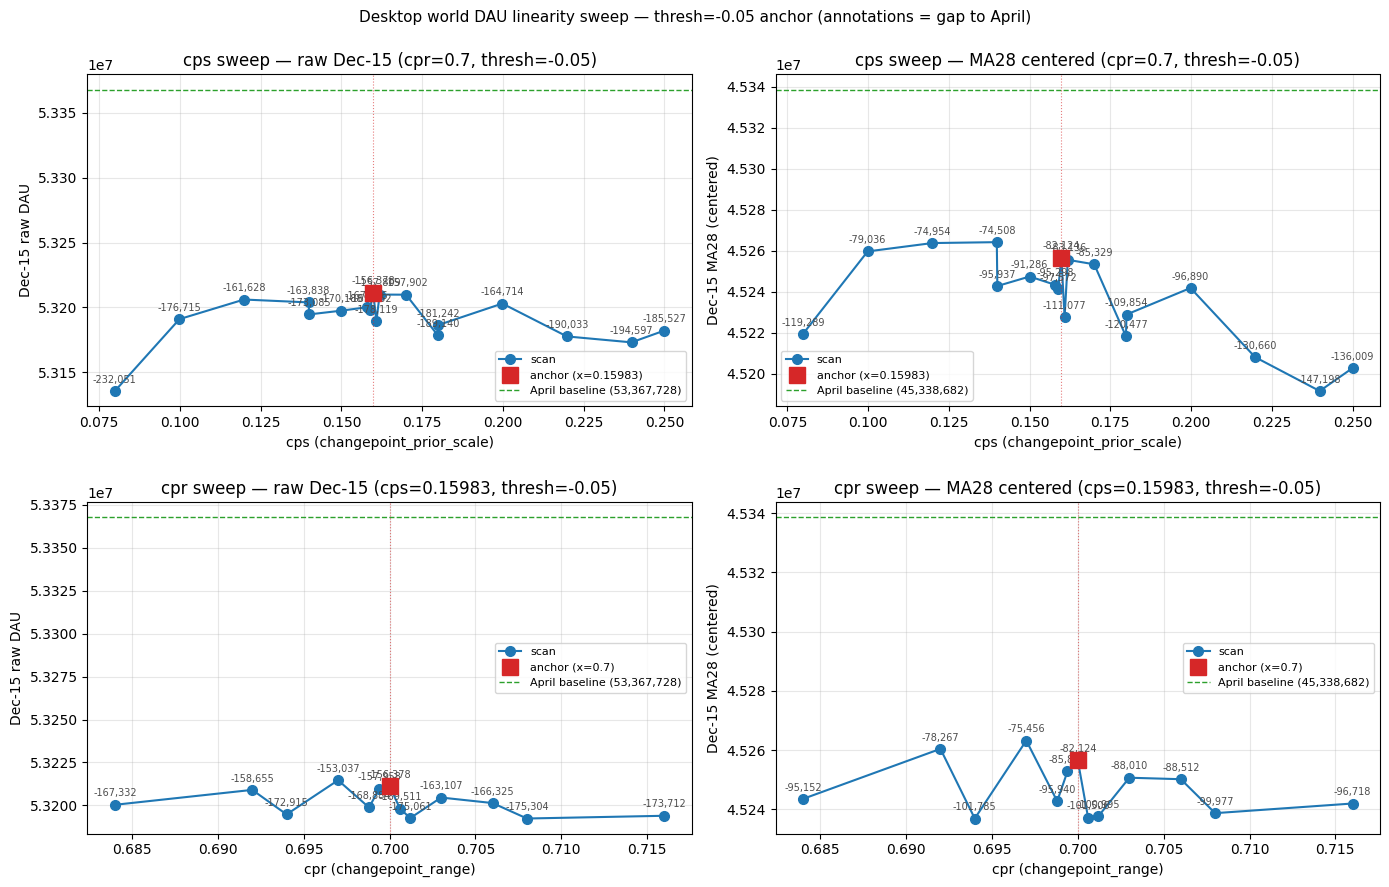

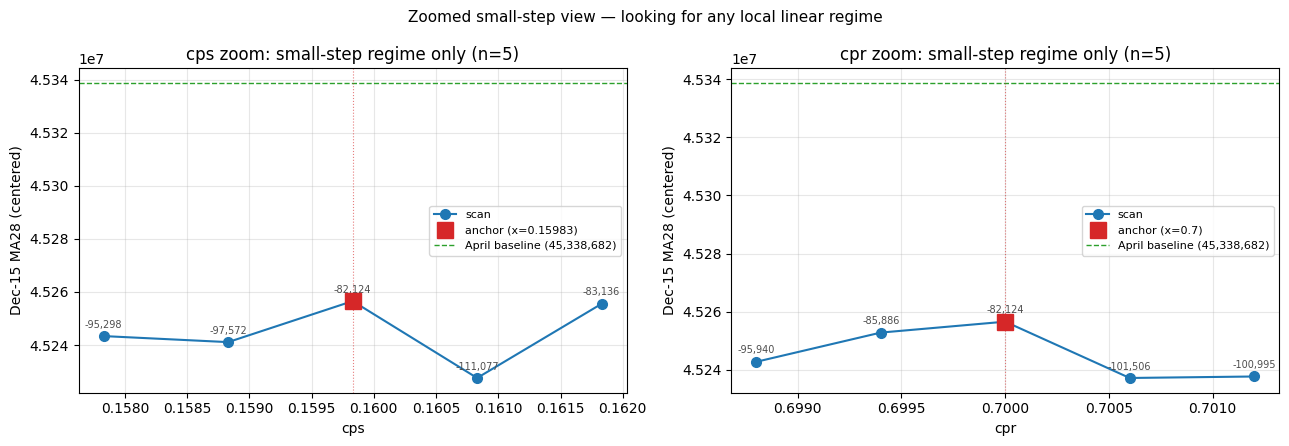

In [6]:
# [linearity-plot]
# Scan-axis filtering: thresh=-0.05, recent=13, ncp=25, clip=-0.6 (the other knobs at defaults).
# cps axis: cpr held at 0.7. cpr axis: cps held at 0.15983.
# Plot both MA28 centered Dec-15 and raw Dec-15.

ANCHOR_DATE = pd.Timestamp("2026-12-15")
SEG_ALL = '{"os": "ALL"}'


def dec15_world_both(parquet_path: Path) -> tuple[float, float]:
    """Return (raw_Dec15, MA28_centered_Dec15) for desktop world DAU at country=ALL, os=ALL."""
    df, _ = load_forecast(parquet_path, require_state=[])
    w = df[(df["country"] == "ALL") & (df["segment"] == SEG_ALL)].copy()
    w["target_date"] = pd.to_datetime(w["target_date"])
    w = w.sort_values("target_date").set_index("target_date")
    raw = float(w.loc[ANCHOR_DATE, "dau"])
    ma28_c = float(w["dau"].rolling(28, center=True, min_periods=14).mean().loc[ANCHOR_DATE])
    return raw, ma28_c


def cfg_of(slug_dir: Path) -> dict:
    return json.loads((slug_dir / "parameters.json").read_text())["config"]


# Reference values
april_raw, april_mac = dec15_world_both(APRIL_BASELINE_PARQUET)
print(f"April baseline: raw={april_raw:,.0f}, MA28c={april_mac:,.0f}")

ANCHOR_DIR = REPO_ROOT / "param_scan_results/cps0.15983_thresh050_recent13_cpr0.7_ncp25_clip0.6"
anc_raw, anc_mac = dec15_world_both(ANCHOR_DIR / "mozaic_daily_forecast.2026-05-17.ld-D.raw.parquet")
print(f"Anchor (thresh=-0.05, cps=0.15983, cpr=0.7): raw={anc_raw:,.0f}, MA28c={anc_mac:,.0f}")
print(f"  Anchor gap to April: raw {anc_raw-april_raw:+,.0f}, MA28c {anc_mac-april_mac:+,.0f}")

# Walk all scan dirs, filter to "thresh=-0.05 + other-knob-defaults" runs that vary cps OR cpr only
cps_axis: list[tuple[float, float, float]] = [(0.15983, anc_raw, anc_mac)]
cpr_axis: list[tuple[float, float, float]] = [(0.7, anc_raw, anc_mac)]
for d in sorted((REPO_ROOT / "param_scan_results").glob("*")):
    if not d.is_dir() or not (d / "parameters.json").exists():
        continue
    c = cfg_of(d)
    if abs(c["holiday_threshold"] - (-0.05)) > 1e-6:
        continue
    if c["prophet_recent_weeks"] != 13:
        continue
    if c["prophet_n_changepoints"] != 25:
        continue
    if abs(c["holiday_effect_floor"] - (-0.6)) > 1e-6:
        continue
    cps = c["prophet_changepoint_prior_scale"]
    cpr = c["prophet_changepoint_range"]
    if abs(cps - 0.15983) < 1e-6 and abs(cpr - 0.7) < 1e-6:
        continue  # anchor itself
    parquet = next(d.glob("mozaic_daily_forecast.*.ld-D.raw.parquet"))
    raw, mac = dec15_world_both(parquet)
    if abs(cpr - 0.7) < 1e-6:
        cps_axis.append((cps, raw, mac))
    if abs(cps - 0.15983) < 1e-6:
        cpr_axis.append((cpr, raw, mac))

cps_axis.sort()
cpr_axis.sort()
print(f"\ncps axis points (cpr=0.7): {len(cps_axis)}")
print(f"cpr axis points (cps=0.15983): {len(cpr_axis)}")


# 2x2 grid: cps (raw, MA28c) and cpr (raw, MA28c)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

def plot_axis(ax, points, anchor_x, anchor_y, april_y, x_label, y_label, title):
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    ax.plot(xs, ys, "o-", color="tab:blue", lw=1.5, ms=7, label="scan")
    # Anchor marker
    ax.plot([anchor_x], [anchor_y], "s", color="tab:red", ms=11, label=f"anchor (x={anchor_x:g})", zorder=5)
    # April baseline line
    ax.axhline(april_y, color="tab:green", ls="--", lw=1, label=f"April baseline ({april_y:,.0f})")
    # Anchor vertical guide
    ax.axvline(anchor_x, color="tab:red", ls=":", lw=0.8, alpha=0.6)
    # Annotations: gap vs April for each point
    for x, y in zip(xs, ys):
        ax.annotate(f"{y-april_y:+,.0f}", (x, y), xytext=(0, 6), textcoords="offset points",
                    ha="center", fontsize=7, color="0.3")
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="best")


# cps row
plot_axis(axes[0, 0],
          [(cps, raw) for cps, raw, _ in cps_axis], 0.15983, anc_raw, april_raw,
          "cps (changepoint_prior_scale)", "Dec-15 raw DAU",
          f"cps sweep — raw Dec-15 (cpr=0.7, thresh=-0.05)")
plot_axis(axes[0, 1],
          [(cps, mac) for cps, _, mac in cps_axis], 0.15983, anc_mac, april_mac,
          "cps (changepoint_prior_scale)", "Dec-15 MA28 (centered)",
          f"cps sweep — MA28 centered (cpr=0.7, thresh=-0.05)")

# cpr row
plot_axis(axes[1, 0],
          [(cpr, raw) for cpr, raw, _ in cpr_axis], 0.7, anc_raw, april_raw,
          "cpr (changepoint_range)", "Dec-15 raw DAU",
          f"cpr sweep — raw Dec-15 (cps=0.15983, thresh=-0.05)")
plot_axis(axes[1, 1],
          [(cpr, mac) for cpr, _, mac in cpr_axis], 0.7, anc_mac, april_mac,
          "cpr (changepoint_range)", "Dec-15 MA28 (centered)",
          f"cpr sweep — MA28 centered (cps=0.15983, thresh=-0.05)")

fig.suptitle(
    "Desktop world DAU linearity sweep — thresh=-0.05 anchor "
    "(annotations = gap to April)",
    fontsize=11,
)
fig.tight_layout()
plt.show()


# Also a zoomed view of the small-step regime alone (±2 small steps around anchor)
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 4.5))
cps_zoom = [p for p in cps_axis if 0.157 <= p[0] <= 0.163]
cpr_zoom = [p for p in cpr_axis if 0.698 <= p[0] <= 0.702]

plot_axis(axes2[0],
          [(cps, mac) for cps, _, mac in cps_zoom], 0.15983, anc_mac, april_mac,
          "cps", "Dec-15 MA28 (centered)",
          f"cps zoom: small-step regime only (n={len(cps_zoom)})")
plot_axis(axes2[1],
          [(cpr, mac) for cpr, _, mac in cpr_zoom], 0.7, anc_mac, april_mac,
          "cpr", "Dec-15 MA28 (centered)",
          f"cpr zoom: small-step regime only (n={len(cpr_zoom)})")
fig2.suptitle("Zoomed small-step view — looking for any local linear regime", fontsize=11)
fig2.tight_layout()
plt.show()


In [7]:
# [next-step-recommendation]
# Heuristic: for each parameter that varies, fit slope of dec15_world_dau vs param.
# The sign tells us which direction moves the forecast toward the April baseline.
# Recommend stepping further in that direction from the best run so far.

JUNE_DEFAULTS = {
    "changepoint_prior_scale": 0.15983,
    "recent_weeks": 13,
    "changepoint_range": 0.7,
    "n_changepoints": 25,
    "holiday_threshold": -0.05,
    "holiday_effect_floor": -0.6,
}

STEP_SIZES = {
    "changepoint_prior_scale": 0.05,   # additive step
    "recent_weeks": 4,                 # weeks
    "changepoint_range": 0.05,         # 0..1
    "n_changepoints": 10,              # count
    "holiday_threshold": 0.01,         # smaller magnitude = more permissive
    "holiday_effect_floor": 0.1,       # closer to 0 = less clipping
}


def recommend_next_configs(df: pd.DataFrame, baselines: dict,
                           max_recs: int = 3) -> list[dict]:
    if df.empty:
        print("No runs yet. See the empty-state cell below for starting configs.")
        return []

    target = baselines["april_point"]
    best_idx = (df["dec15_world_dau"] - target).abs().idxmin()
    best_row = df.loc[best_idx]
    best_gap = target - best_row["dec15_world_dau"]
    direction = +1 if best_gap > 0 else -1

    print(f"Best run so far: {best_idx}")
    print(f"  Dec 15 DAU: {best_row['dec15_world_dau']:,.0f}")
    print(f"  Gap to April: {best_gap:+,.0f}")
    print(f"  Need to move forecast {'UP' if direction > 0 else 'DOWN'}")
    print()

    # Per-param slope (only meaningful when that param varies)
    slopes = {}
    for param in SCAN_PARAMS:
        sub = df.dropna(subset=[param, "dec15_world_dau"])
        if sub[param].nunique() >= 2:
            xs = sub[param].astype(float).values
            ys = sub["dec15_world_dau"].astype(float).values
            slope = np.polyfit(xs, ys, 1)[0]
            slopes[param] = slope

    if not slopes:
        print("No parameter has varied yet — pick one knob and run two configs that")
        print("differ only on that knob to establish a slope.")
        # Suggest stepping each scannable knob from the best run in BOTH directions.
        recs = []
        for param, step in list(STEP_SIZES.items())[:max_recs]:
            base = best_row[param] if pd.notna(best_row[param]) else JUNE_DEFAULTS[param]
            recs.append({param: float(base) + step})
        return recs

    print("Estimated slopes (Δ DAU per +1 unit of param):")
    for p, s in slopes.items():
        print(f"  {p:30s}: {s:>+15,.0f}")
    print()

    # For each param: step in the direction that moves DAU toward target.
    recs = []
    for param, slope in sorted(slopes.items(), key=lambda kv: -abs(kv[1])):
        if abs(slope) < 1.0:
            continue  # essentially no sensitivity
        step_dir = +1 if (slope > 0) == (direction > 0) else -1
        step = STEP_SIZES[param] * step_dir
        base = best_row[param] if pd.notna(best_row[param]) else JUNE_DEFAULTS[param]
        new_val = float(base) + step
        recs.append({param: new_val})
        if len(recs) >= max_recs:
            break
    return recs


def format_rec_as_cli(rec: dict, base_cmd: str) -> str:
    flag_map = {
        "changepoint_prior_scale": "--changepoint-prior-scale",
        "recent_weeks":            "--recent-weeks",
        "changepoint_range":       "--changepoint-range",
        "n_changepoints":          "--n-changepoints",
        "holiday_threshold":       "--holiday-threshold",
        "holiday_max_radius":      "--holiday-max-radius",
        "holiday_min_radius":      "--holiday-min-radius",
        "holiday_effect_floor":    "--holiday-effect-floor",
    }
    flags = " ".join(f"{flag_map[k]} {v}" for k, v in rec.items())
    return f"{base_cmd} {flags}"


BASE_CMD = (
    "python scripts/run_param_scan.py "
    "--forecast-start-date 2026-05-17 "
    "--raw-cache-dir <first-completed-slug-dir>"
)

recs = recommend_next_configs(results, baselines)
if recs:
    print(f"\nRecommended next configs (top {len(recs)}):")
    for i, rec in enumerate(recs, 1):
        print(f"\n  [{i}] vary: {rec}")
        print(f"      $ {format_rec_as_cli(rec, BASE_CMD)}")



Best run so far: cps0.15983_thresh032_recent13_cpr0.5_ncp25_clip0.6
  Dec 15 DAU: 53,218,832
  Gap to April: +148,896
  Need to move forecast UP

Estimated slopes (Δ DAU per +1 unit of param):
  changepoint_prior_scale       :         +19,110
  recent_weeks                  :        +147,082
  changepoint_range             :        -217,040
  n_changepoints                :          -2,278
  holiday_threshold             :      -9,758,837
  holiday_effect_floor          :        +154,474


Recommended next configs (top 3):

  [1] vary: {'holiday_threshold': -0.042}
      $ python scripts/run_param_scan.py --forecast-start-date 2026-05-17 --raw-cache-dir <first-completed-slug-dir> --holiday-threshold -0.042

  [2] vary: {'changepoint_range': 0.45}
      $ python scripts/run_param_scan.py --forecast-start-date 2026-05-17 --raw-cache-dir <first-completed-slug-dir> --changepoint-range 0.45

  [3] vary: {'holiday_effect_floor': -0.5}
      $ python scripts/run_param_scan.py --forecast-start

In [8]:
# [empty-state-starting-configs]
# Shows starting configs when no scan runs exist. Safe to leave in even
# after results accumulate — it just prints suggestions.
#
# Each starting config is one knob varied from the June cap-426 baseline.
# The cap-426 baseline used config=None in main.py → package defaults:
#   cps=0.15983, recent_weeks=13, changepoint_range=0.7, n_changepoints=25,
#   holiday_threshold=-0.032, holiday_effect_floor=-0.6
# So the baseline slug under run_param_scan.py with no overrides is:
#   cps0.15983_thresh032_recent13_cpr0.7_ncp25_clip0.6

STARTING_CONFIGS = [
    {
        "note": "1. Match April's actual holiday_threshold (-0.05). April was manually overridden; "
                "June cap-426 used the package default -0.032. Closing this single difference is "
                "the cheapest first 'match April' check.",
        "flags": "--holiday-threshold -0.05",
    },
    {
        "note": "2. Lower changepoint_prior_scale to smooth the recent trend (less aggressive downward).",
        "flags": "--changepoint-prior-scale 0.10",
    },
    {
        "note": "3. Pull changepoint_range back so trend changepoints stop earlier (less reactive to the tail).",
        "flags": "--changepoint-range 0.5",
    },
    {
        "note": "4. Shorten recent-weeks so conditional weekly seasonality leans on broader history.",
        "flags": "--recent-weeks 8",
    },
]

# The cap-426 dir holds the raw BQ checkpoints we want to reuse so each scan run
# skips the (slow) BQ step. Pass it as --raw-cache-dir on every scan invocation.
RAW_CACHE_DIR = (
    "data-official/2026-06/desktop_cps0.15983_thresh032_recent13_clip0.6_cap426"
)

BASE = (
    "python scripts/run_param_scan.py "
    "--forecast-start-date 2026-05-17 "
    f"--raw-cache-dir {RAW_CACHE_DIR}"
)

if results.empty:
    print("No scan runs yet. Suggested starting configs (run each as its own command):\n")
else:
    print("Reference: starting configs (already covered by your scan if listed above).\n")

for cfg in STARTING_CONFIGS:
    print(f"  {cfg['note']}")
    cmd = f"{BASE} {cfg['flags']}".rstrip()
    print(f"    $ {cmd}\n")

print("Sandbox note: `dangerouslyDisableSandbox: true` (or `/sandbox` to add hosts) is required")
print("even when --raw-cache-dir is set — main.py runs a BQ Storage API pre-flight check that")
print("hits a host outside the sandbox's default allowlist.")


Reference: starting configs (already covered by your scan if listed above).

  1. Match April's actual holiday_threshold (-0.05). April was manually overridden; June cap-426 used the package default -0.032. Closing this single difference is the cheapest first 'match April' check.
    $ python scripts/run_param_scan.py --forecast-start-date 2026-05-17 --raw-cache-dir data-official/2026-06/desktop_cps0.15983_thresh032_recent13_clip0.6_cap426 --holiday-threshold -0.05

  2. Lower changepoint_prior_scale to smooth the recent trend (less aggressive downward).
    $ python scripts/run_param_scan.py --forecast-start-date 2026-05-17 --raw-cache-dir data-official/2026-06/desktop_cps0.15983_thresh032_recent13_clip0.6_cap426 --changepoint-prior-scale 0.10

  3. Pull changepoint_range back so trend changepoints stop earlier (less reactive to the tail).
    $ python scripts/run_param_scan.py --forecast-start-date 2026-05-17 --raw-cache-dir data-official/2026-06/desktop_cps0.15983_thresh032_recent13

cps axis: 18 runs, params = ['0.07983', '0.09983', '0.11983', '0.13983', '0.14000', '0.15000', '0.15783', '0.15883', '0.15983', '0.16083', '0.16183', '0.17000', '0.17983', '0.18000', '0.19983', '0.21983', '0.23983', '0.25000']
cpr axis: 13 runs, params = ['0.68400', '0.69200', '0.69400', '0.69700', '0.69880', '0.69940', '0.70000', '0.70060', '0.70120', '0.70300', '0.70600', '0.70800', '0.71600']


/var/folders/kv/n1zbn8ks1b3b_9083hxscy2m0000gn/T/ipykernel_80747/2977138296.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("coolwarm", n)


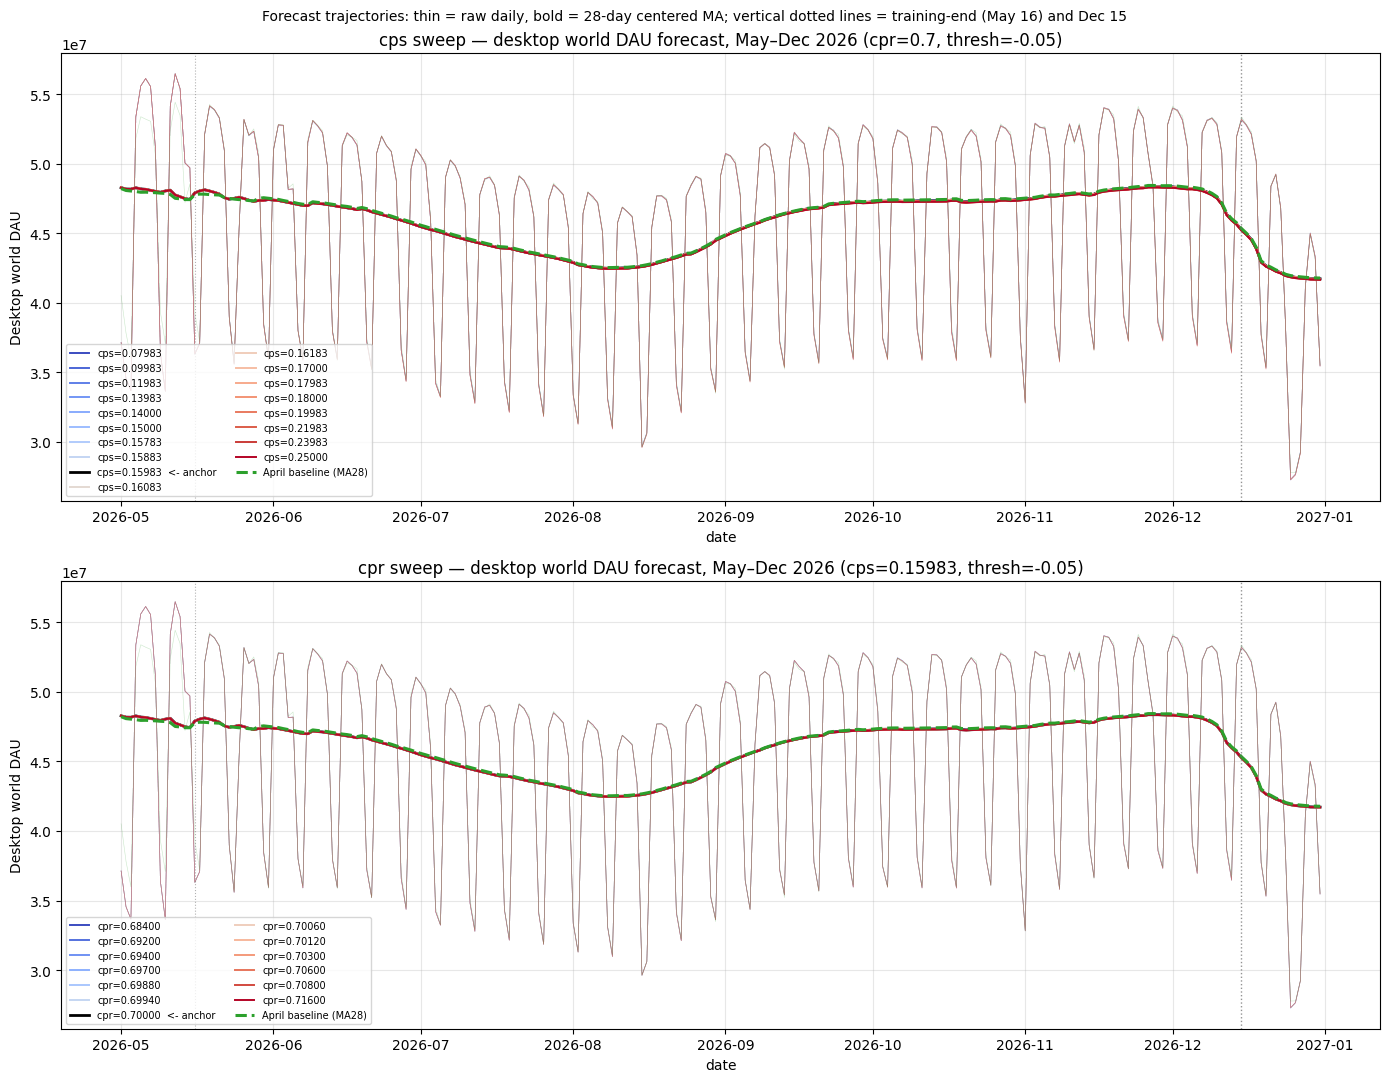

/var/folders/kv/n1zbn8ks1b3b_9083hxscy2m0000gn/T/ipykernel_80747/2977138296.py:120: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("coolwarm", n)


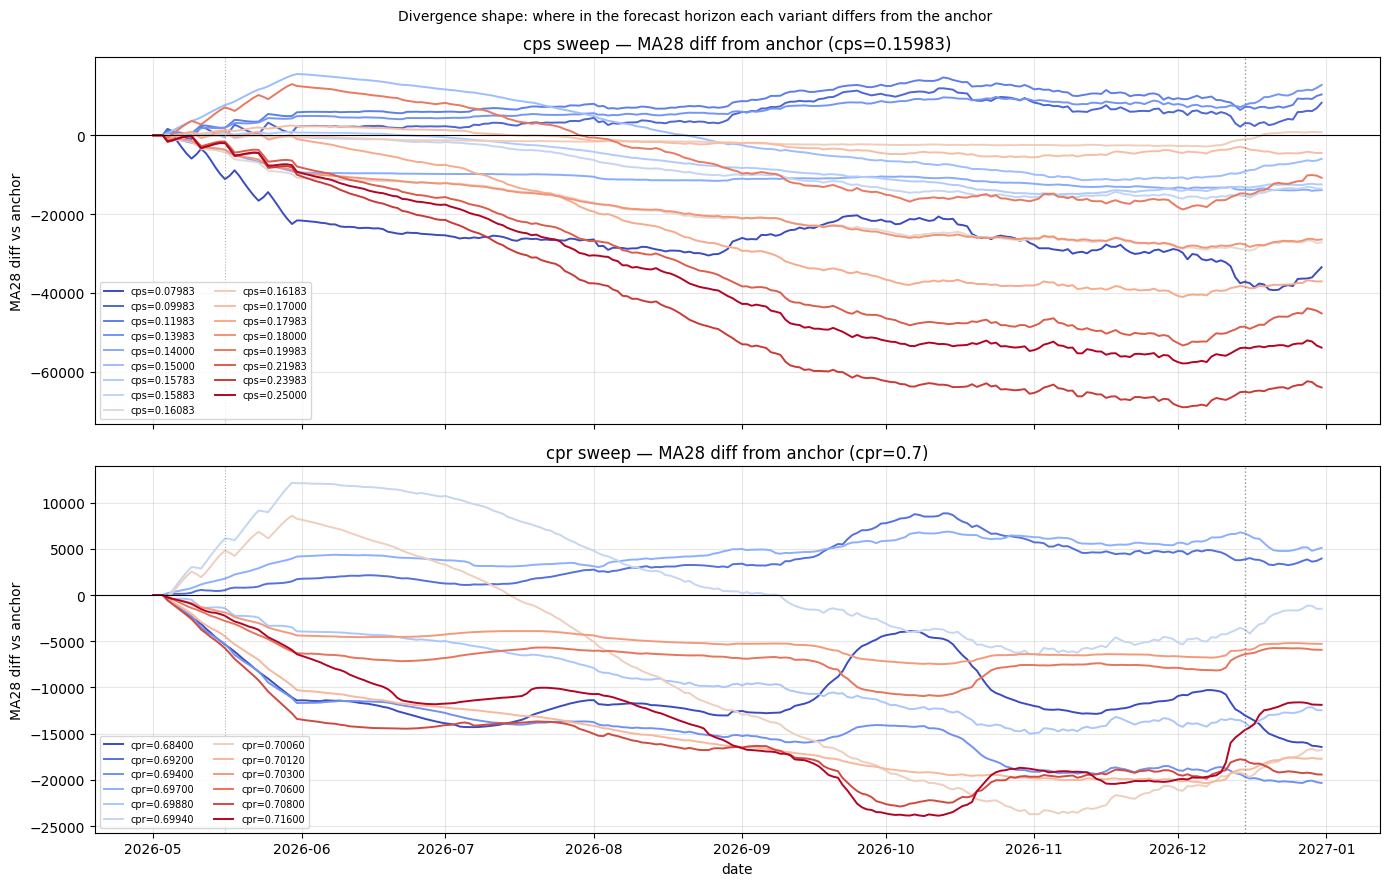

In [9]:
# [forecast-curves]
# Overlay the forecast trajectories for each cps and cpr variant (May 2026 -> Dec 2026)
# so the shape of disagreement is visible, not just the Dec-15 endpoint.
#
# For each axis (cps, cpr), one panel of raw daily DAU (alpha low) plus 28-day centered MA
# (bold). Anchor highlighted in red, April baseline overlaid in green, Dec-15 marked.

import matplotlib.cm as cm
from matplotlib.lines import Line2D

PLOT_START = pd.Timestamp("2026-05-01")
PLOT_END = pd.Timestamp("2026-12-31")


def world_series(parquet_path: Path) -> pd.DataFrame:
    """Return desktop world DAU time series, country=ALL/os=ALL, with MA28 added."""
    df, _ = load_forecast(parquet_path, require_state=[])
    w = df[(df["country"] == "ALL") & (df["segment"] == SEG_ALL)].copy()
    w["target_date"] = pd.to_datetime(w["target_date"])
    w = w.sort_values("target_date").set_index("target_date")
    w["ma28_c"] = w["dau"].rolling(28, center=True, min_periods=14).mean()
    return w


# Build the lists of (param_value, dataframe, label) for each axis. Anchor is a special label.
ANCHOR_PARQUET = ANCHOR_DIR / "mozaic_daily_forecast.2026-05-17.ld-D.raw.parquet"
anchor_df = world_series(ANCHOR_PARQUET)
april_df = world_series(APRIL_BASELINE_PARQUET)


def collect_axis(varied: str) -> list[tuple[float, pd.DataFrame]]:
    """Return [(param_value, series_df), ...] for one axis (cps or cpr).

    Filters to thresh=-0.05, recent=13, ncp=25, clip=-0.6 runs that vary only the named axis.
    Adds the anchor (cps=0.15983, cpr=0.7) as one of the points.
    """
    out = [(0.15983 if varied == "cps" else 0.7, anchor_df)]
    for d in sorted((REPO_ROOT / "param_scan_results").glob("*")):
        if not d.is_dir() or not (d / "parameters.json").exists():
            continue
        c = json.loads((d / "parameters.json").read_text())["config"]
        if abs(c["holiday_threshold"] - (-0.05)) > 1e-6: continue
        if c["prophet_recent_weeks"] != 13: continue
        if c["prophet_n_changepoints"] != 25: continue
        if abs(c["holiday_effect_floor"] - (-0.6)) > 1e-6: continue
        cps = c["prophet_changepoint_prior_scale"]
        cpr = c["prophet_changepoint_range"]
        if abs(cps - 0.15983) < 1e-6 and abs(cpr - 0.7) < 1e-6:
            continue  # anchor itself
        if varied == "cps" and abs(cpr - 0.7) < 1e-6 and abs(cps - 0.15983) > 1e-6:
            parquet = next(d.glob("mozaic_daily_forecast.*.ld-D.raw.parquet"))
            out.append((cps, world_series(parquet)))
        elif varied == "cpr" and abs(cps - 0.15983) < 1e-6 and abs(cpr - 0.7) > 1e-6:
            parquet = next(d.glob("mozaic_daily_forecast.*.ld-D.raw.parquet"))
            out.append((cpr, world_series(parquet)))
    out.sort(key=lambda r: r[0])
    return out


cps_runs = collect_axis("cps")
cpr_runs = collect_axis("cpr")
print(f"cps axis: {len(cps_runs)} runs, params = {[f'{v:.5f}' for v, _ in cps_runs]}")
print(f"cpr axis: {len(cpr_runs)} runs, params = {[f'{v:.5f}' for v, _ in cpr_runs]}")


def plot_axis(ax, runs, anchor_value, label_prefix):
    n = len(runs)
    # Diverging colormap, anchor in red
    cmap = cm.get_cmap("coolwarm", n)
    for i, (val, ser) in enumerate(runs):
        is_anchor = abs(val - anchor_value) < 1e-6
        color = "black" if is_anchor else cmap(i / max(n - 1, 1))
        lw = 2.0 if is_anchor else 1.4
        sub = ser[(ser.index >= PLOT_START) & (ser.index <= PLOT_END)]
        # Faint raw daily
        ax.plot(sub.index, sub["dau"], color=color, lw=0.4, alpha=0.20)
        # Bold MA28
        ax.plot(sub.index, sub["ma28_c"], color=color, lw=lw,
                label=f"{label_prefix}={val:.5f}" + ("  <- anchor" if is_anchor else ""))

    # April baseline overlay
    apr_sub = april_df[(april_df.index >= PLOT_START) & (april_df.index <= PLOT_END)]
    ax.plot(apr_sub.index, apr_sub["dau"], color="tab:green", lw=0.4, alpha=0.25)
    ax.plot(apr_sub.index, apr_sub["ma28_c"], color="tab:green", lw=2.2, ls="--",
            label="April baseline (MA28)")

    # Dec-15 marker
    ax.axvline(pd.Timestamp("2026-12-15"), color="0.4", ls=":", lw=1, alpha=0.7)
    # Training/forecast boundary for June runs: training ends 2026-05-16
    ax.axvline(pd.Timestamp("2026-05-16"), color="0.5", ls=":", lw=0.8, alpha=0.6)

    ax.set_xlabel("date")
    ax.set_ylabel("Desktop world DAU")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc="lower left", ncol=2)


fig, axes = plt.subplots(2, 1, figsize=(14, 11))
plot_axis(axes[0], cps_runs, 0.15983, "cps")
axes[0].set_title("cps sweep — desktop world DAU forecast, May–Dec 2026 (cpr=0.7, thresh=-0.05)")

plot_axis(axes[1], cpr_runs, 0.7, "cpr")
axes[1].set_title("cpr sweep — desktop world DAU forecast, May–Dec 2026 (cps=0.15983, thresh=-0.05)")

fig.suptitle(
    "Forecast trajectories: thin = raw daily, bold = 28-day centered MA; "
    "vertical dotted lines = training-end (May 16) and Dec 15",
    fontsize=10,
)
fig.tight_layout()
plt.show()


# Diff version: each run minus the anchor, so divergence shape is obvious.
fig2, axes2 = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
anchor_ma = anchor_df["ma28_c"]

def plot_diff(ax, runs, anchor_value, label_prefix):
    n = len(runs)
    cmap = cm.get_cmap("coolwarm", n)
    for i, (val, ser) in enumerate(runs):
        is_anchor = abs(val - anchor_value) < 1e-6
        if is_anchor:
            continue
        diff = (ser["ma28_c"] - anchor_ma)
        sub = diff[(diff.index >= PLOT_START) & (diff.index <= PLOT_END)]
        color = cmap(i / max(n - 1, 1))
        ax.plot(sub.index, sub.values, color=color, lw=1.4,
                label=f"{label_prefix}={val:.5f}")
    ax.axhline(0, color="black", lw=0.8)
    ax.axvline(pd.Timestamp("2026-12-15"), color="0.4", ls=":", lw=1, alpha=0.7)
    ax.axvline(pd.Timestamp("2026-05-16"), color="0.5", ls=":", lw=0.8, alpha=0.6)
    ax.set_ylabel("MA28 diff vs anchor")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc="lower left", ncol=2)

plot_diff(axes2[0], cps_runs, 0.15983, "cps")
axes2[0].set_title("cps sweep — MA28 diff from anchor (cps=0.15983)")
plot_diff(axes2[1], cpr_runs, 0.7, "cpr")
axes2[1].set_title("cpr sweep — MA28 diff from anchor (cpr=0.7)")
axes2[1].set_xlabel("date")
fig2.suptitle("Divergence shape: where in the forecast horizon each variant differs from the anchor",
              fontsize=10)
fig2.tight_layout()
plt.show()
